# Validação de imagens com CNN própria

Este notebook adiciona a parte de imagem do projeto usando a base **COVID-19 Radiography Database**.

A ideia aqui é treinar um modelo simples de CNN do zero, sem usar modelo pronto de transferência de aprendizado. Para melhorar o aprendizado, vamos usar **data augmentation**, que cria pequenas variações das imagens de treino durante o treinamento.

Importante: este notebook é uma validação complementar. O modelo tabular continua sendo uma parte separada do projeto.

In [1]:
# Esta célula garante que o notebook consiga enxergar a pasta src do projeto.
# Como o notebook está dentro da pasta notebooks, precisamos adicionar a raiz do projeto no sys.path.

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Raiz do projeto:", PROJECT_ROOT)

Raiz do projeto: c:\Users\icaro\OneDrive\Área de Trabalho\ml-tech-challenge


In [2]:
# Imports principais do notebook.
# Separar os imports em uma célula ajuda a identificar rapidamente se falta alguma biblioteca instalada.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Carregamento das imagens

As imagens vêm do Kaggle, usando o `kagglehub`. A função `load_images` ficou no arquivo `src/image/image_data.py`, para deixar o notebook mais limpo e reutilizar o código em outros pontos do projeto.

Para não travar a máquina durante os testes, usamos `max_images_per_class`. Se o notebook ficar pesado, reduza para 100 ou 150. Se quiser um treino melhor, aumente para 300 ou mais.

In [3]:
from src.image.image_data import load_images

# Quantidade máxima de imagens por classe.
# Para teste rápido: 50 ou 100.
# Para um teste mais realista: 300 ou mais, se a máquina aguentar.
MAX_IMAGES_PER_CLASS = 300
IMAGE_SIZE = (224, 224)

X, y, class_names = load_images(
    image_size=IMAGE_SIZE,
    max_images_per_class=MAX_IMAGES_PER_CLASS
)

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)
print("Classes:", class_names)

c:\Users\icaro\anaconda3\envs\ia\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Formato de X: (1200, 224, 224, 3)
Formato de y: (1200,)
Classes: ['COVID', 'Normal', 'Lung_Opacity', 'Viral Pneumonia']


## 2. Visualização inicial

Antes de treinar qualquer modelo, é importante olhar algumas imagens. Isso ajuda a confirmar se o carregamento está correto, se as classes fazem sentido e se as imagens não vieram corrompidas.

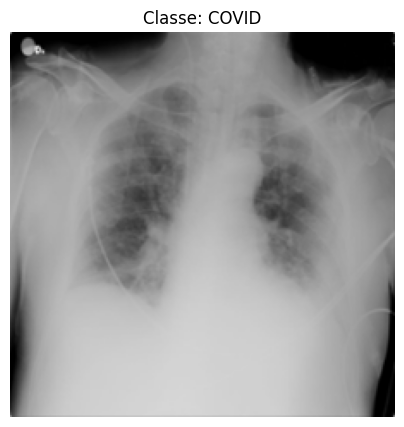

In [4]:
# Mostrando uma imagem isolada só para confirmar se o array virou imagem corretamente.

idx = 0

plt.figure(figsize=(5, 5))
plt.imshow(X[idx].astype("uint8"))
plt.title(f"Classe: {class_names[y[idx]]}")
plt.axis("off")
plt.show()

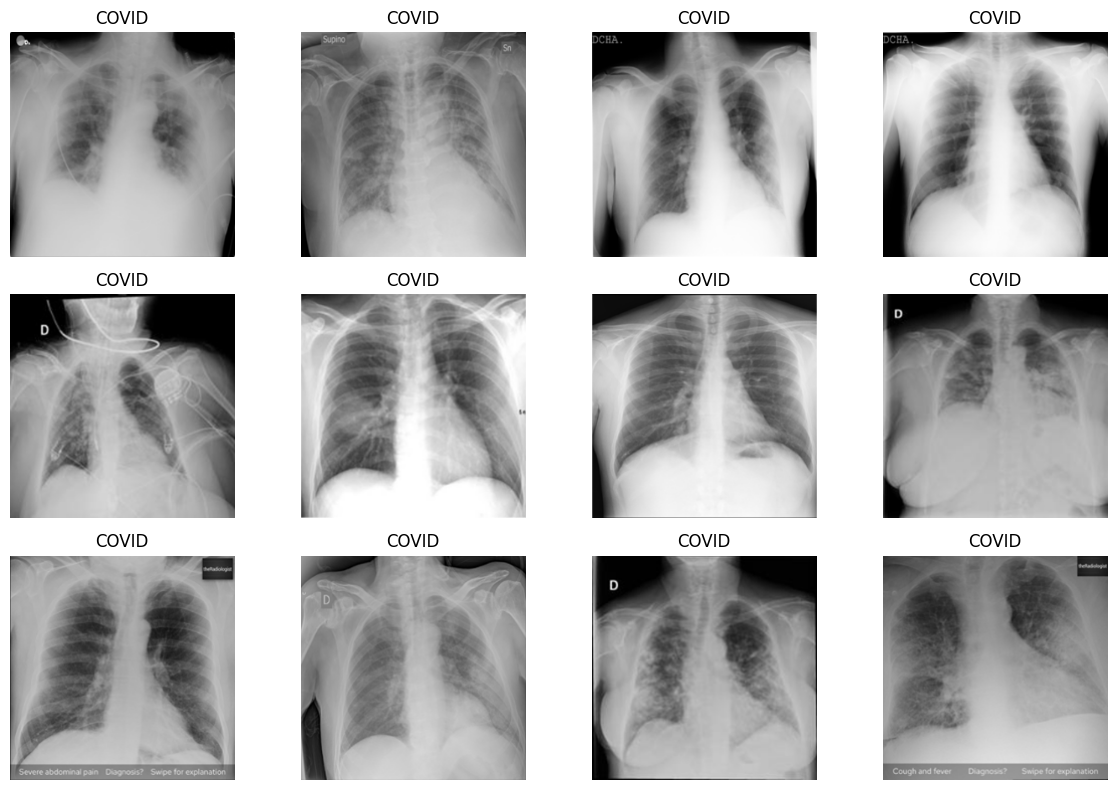

In [5]:
# Agora vamos ver uma amostra com várias classes.
# Isso é útil para verificar se o dataset está carregando classes diferentes mesmo.

plt.figure(figsize=(12, 8))

for i in range(min(12, len(X))):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X[i].astype("uint8"))
    plt.title(class_names[y[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 3. Distribuição das classes

Aqui conferimos se as classes estão balanceadas. Como usamos `max_images_per_class`, a tendência é cada classe ter a mesma quantidade de imagens.

Isso é importante porque, se uma classe tiver muito mais exemplos que as outras, o modelo pode aprender a favorecer essa classe.

COVID              300
Normal             300
Lung_Opacity       300
Viral Pneumonia    300
Name: count, dtype: int64


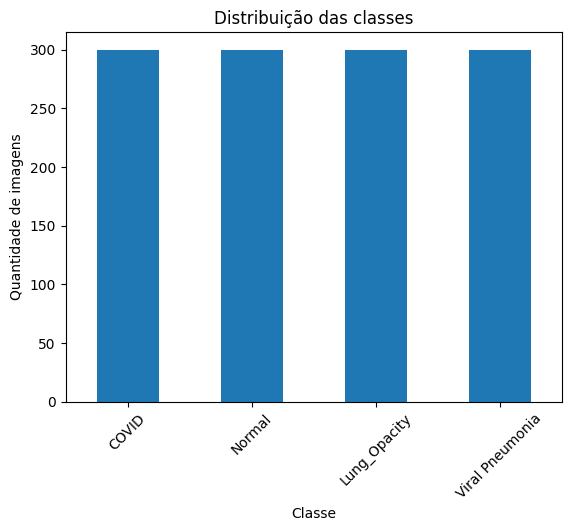

In [6]:
class_distribution = (
    pd.Series(y)
    .value_counts()
    .sort_index()
    .rename(index=dict(enumerate(class_names)))
)

print(class_distribution)

class_distribution.plot(kind="bar", title="Distribuição das classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade de imagens")
plt.xticks(rotation=45)
plt.show()

## 4. Pré-processamento

Nesta etapa fazemos duas coisas:

1. normalizamos os pixels para ficarem entre 0 e 1;
2. dividimos os dados em treino e teste.

Também criamos o `ImageDataGenerator`, que faz pequenas alterações nas imagens de treino durante o treinamento. Isso é o **data augmentation**.

A ideia não é inventar imagens totalmente novas, mas criar pequenas variações, como leve rotação, zoom e deslocamento. Isso ajuda o modelo a não decorar as imagens originais.

In [7]:
# Tentamos importar a função de data augmentation do src.
# Se ela ainda não existir no arquivo image_preprocessing.py, criamos a função aqui no notebook mesmo.
# Assim o notebook continua rodando e fica claro qual ajuste deve ir para o projeto depois.

from src.image.image_preprocessing import preprocess_images

try:
    from src.image.image_preprocessing import create_image_augmentation
except ImportError:
    from tensorflow.keras.preprocessing.image import ImageDataGenerator

    def create_image_augmentation():
        """
        Cria o gerador de aumento de dados para imagens.
        Mantive transformações leves porque radiografias não devem ser distorcidas demais.
        """
        return ImageDataGenerator(
            rotation_range=10,
            zoom_range=0.1,
            width_shift_range=0.05,
            height_shift_range=0.05,
            horizontal_flip=True
        )

X_train, X_test, y_train, y_test = preprocess_images(X, y)

datagen = create_image_augmentation()
datagen.fit(X_train)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (960, 224, 224, 3)
X_test: (240, 224, 224, 3)
y_train: (960,)
y_test: (240,)


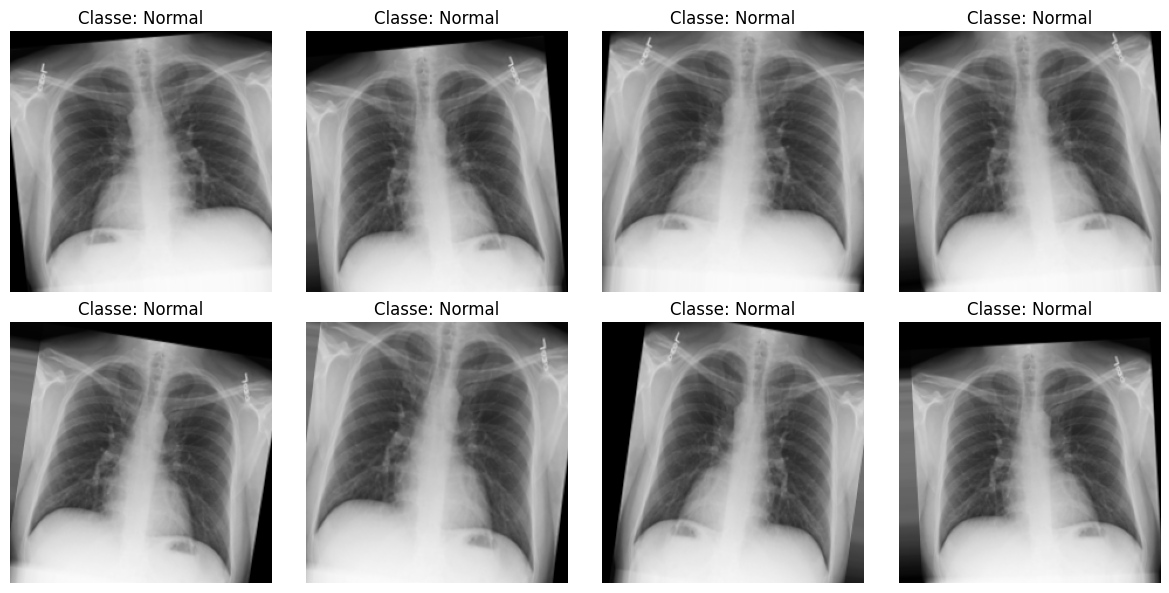

In [8]:
# Vamos visualizar algumas imagens aumentadas.
# Isso ajuda a mostrar para a professora o que o data augmentation está fazendo na prática.

sample_image = X_train[0]
sample_label = y_train[0]

augmented_images = datagen.flow(
    np.expand_dims(sample_image, axis=0),
    np.array([sample_label]),
    batch_size=1
)

plt.figure(figsize=(12, 6))

for i in range(8):
    img_aug, label_aug = next(augmented_images)
    plt.subplot(2, 4, i + 1)
    plt.imshow(img_aug[0])
    plt.title(f"Classe: {class_names[int(label_aug[0])]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Criação do modelo CNN

O modelo usado aqui é uma CNN simples criada do zero.

Um ponto importante: usamos `GlobalAveragePooling2D` em vez de `Flatten`. Isso reduz muito a quantidade de parâmetros e diminui o risco de overfitting.

Na primeira versão, com `Flatten`, o modelo ficou com mais de 23 milhões de parâmetros. Com `GlobalAveragePooling2D`, ele fica muito menor e mais adequado para esta validação.

In [9]:
from src.image.image_model import create_cnn_model

model = create_cnn_model(
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
    num_classes=len(class_names)
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,812 (93.02 KB)

 Trainable params: 23,812 (93.02 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Treinamento com data augmentation

Agora treinamos o modelo usando o gerador de imagens aumentadas.

O conjunto de teste não recebe data augmentation. Isso é proposital: o teste precisa representar imagens reais, sem alterações artificiais.

Começamos com 15 Epoch. Se o treinamento ficar muito demorado, reduza para 8 ou 10. Se estiver rodando bem, pode aumentar depois.

In [10]:
EPOCHS = 15
BATCH_SIZE = 16

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_test, y_test),
    epochs=EPOCHS
)

Epoch 1/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 287ms/step - accuracy: 0.2344 - loss: 1.3907 - val_accuracy: 0.2542 - val_loss: 1.3839
Epoch 2/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 17s 275ms/step - accuracy: 0.2500 - loss: 1.3866 - val_accuracy: 0.3667 - val_loss: 1.3806
Epoch 3/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 16s 268ms/step - accuracy: 0.3333 - loss: 1.3783 - val_accuracy: 0.3208 - val_loss: 1.3590
Epoch 4/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 17s 274ms/step - accuracy: 0.3177 - loss: 1.3676 - val_accuracy: 0.3917 - val_loss: 1.3315
Epoch 5/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 16s 269ms/step - accuracy: 0.3510 - loss: 1.3426 - val_accuracy: 0.3917 - val_loss: 1.3021
Epoch 6/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 16s 272ms/step - accuracy: 0.3531 - loss: 1.3418 - val_accuracy: 0.3833 - val_loss: 1.2972
Epoch 7/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 16s 271ms/step - accuracy: 0.3708 - loss: 1.3253 - val_accuracy: 0.3875 - val_loss: 1.2930
Epoch 8/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 18s 303ms/step - accuracy: 0.3458 - loss: 1.3171 - val_accu

## 7. Curvas de treinamento

Esses gráficos ajudam a entender se o modelo está aprendendo ou se está apenas decorando.

De forma geral:

- se a acurácia de treino sobe e a de validação não sobe, pode ser overfitting;
- se as duas ficam baixas, o modelo ainda não aprendeu bem;
- se as duas sobem juntas, o comportamento é mais saudável.

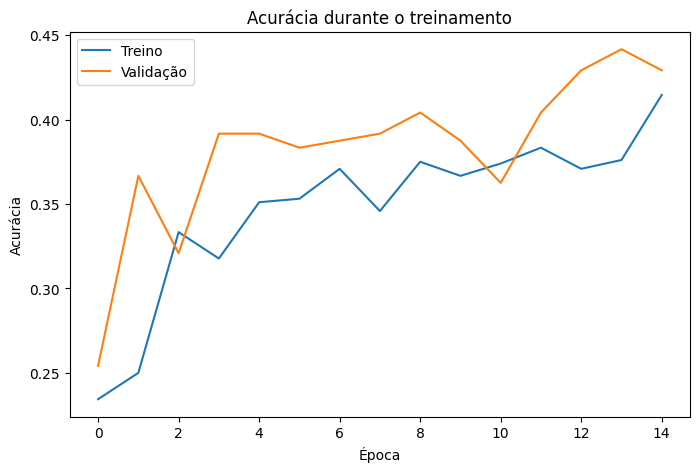

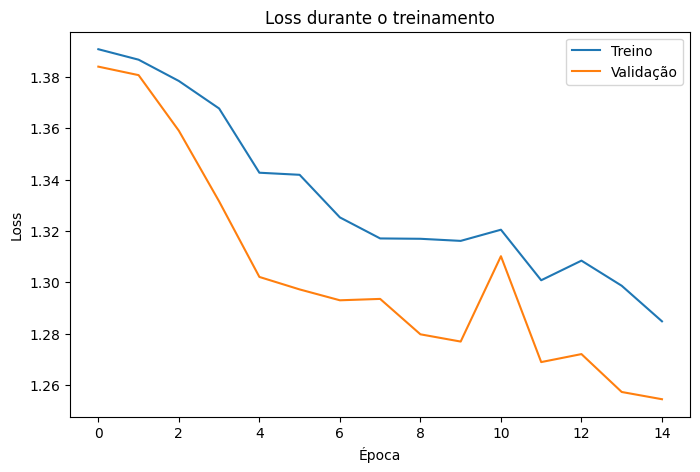

In [11]:
# Gráfico da acurácia.

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Treino")
plt.plot(history.history["val_accuracy"], label="Validação")
plt.title("Acurácia durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.legend()
plt.show()

# Gráfico da perda.

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validação")
plt.title("Loss durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 8. Avaliação final

Nesta etapa avaliamos o modelo no conjunto de teste usando relatório de classificação e matriz de confusão.

A matriz de confusão mostra onde o modelo acertou e onde confundiu uma classe com outra. Ela é muito importante porque a acurácia sozinha pode esconder problemas.

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step
Relatório de classificação:
                 precision    recall  f1-score   support

          COVID       0.48      0.67      0.56        60
         Normal       0.35      0.28      0.31        60
   Lung_Opacity       0.00      0.00      0.00        60
Viral Pneumonia       0.43      0.77      0.55        60

       accuracy                           0.43       240
      macro avg       0.31      0.43      0.35       240
   weighted avg       0.31      0.43      0.35       240



c:\Users\icaro\anaconda3\envs\ia\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\icaro\anaconda3\envs\ia\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\icaro\anaconda3\envs\ia\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


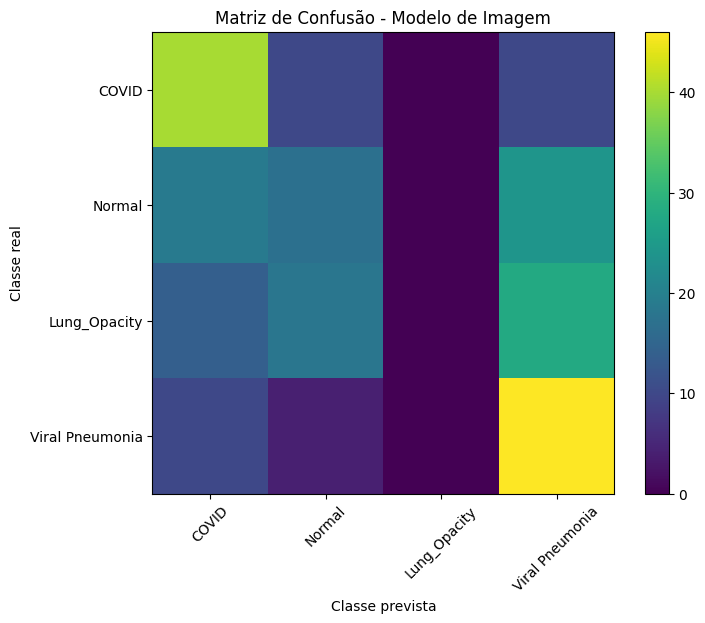

In [12]:
from src.image.image_evaluation import evaluate_image_model

cm = evaluate_image_model(
    model,
    X_test,
    y_test,
    class_names
)

## 9. Teste com uma imagem individual

Aqui fazemos uma predição isolada para visualizar o comportamento do modelo em uma imagem específica do conjunto de teste.

Isso não substitui as métricas, mas ajuda a explicar o resultado de forma mais visual.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


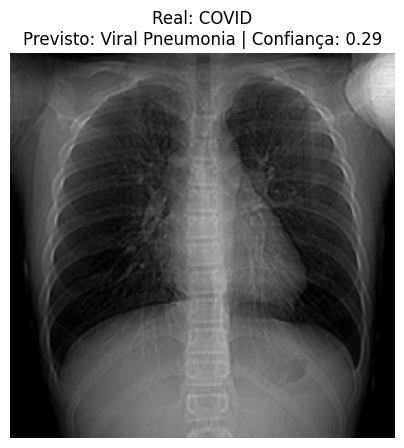

In [13]:
# Escolha um índice qualquer do conjunto de teste.

idx = 0
image = X_test[idx]
real_label = y_test[idx]

prediction = model.predict(np.expand_dims(image, axis=0))
predicted_label = prediction.argmax(axis=1)[0]
confidence = prediction.max()

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(
    f"Real: {class_names[real_label]}\n"
    f"Previsto: {class_names[predicted_label]} | Confiança: {confidence:.2f}"
)
plt.axis("off")
plt.show()

In [14]:

#Salvando o modelo treinado para a pasta results/models.
from pathlib import Path

model_dir = Path("../results/models")
model_dir.mkdir(parents=True, exist_ok=True)

model.save(model_dir / "image_cnn_model.keras")

## 10. Conclusão desta validação

Nesta etapa, criamos uma validação complementar usando imagens de radiografia.

A proposta foi treinar uma CNN própria, sem usar modelo pré-treinado, porque a ideia do trabalho é praticar o pipeline de machine learning e deep learning de ponta a ponta.

O data augmentation foi usado para reduzir o risco de o modelo decorar as imagens de treino. Mesmo assim, por ser uma CNN simples, é esperado que o desempenho ainda possa ser limitado.

Se o modelo continuar confundindo muitas classes, os próximos ajustes possíveis seriam:

- aumentar a quantidade de imagens por classe;
- treinar por mais épocas;
- ajustar a arquitetura da CNN;
- testar regularização, como Dropout;
- comparar com um modelo pré-treinado apenas como estudo futuro, sem substituir a proposta principal.